In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [3]:
pip install pandas numpy matplotlib seaborn openpyxl

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd

df = pd.read_excel(r"C:\Users\USER\Desktop\לימודים\פרויקט גמר ב\סיוג חשבונות באינסטגרם - מאמר מחקר 1 נועה\דאטה סט של מאמר 2 במבנה של דאטה סט של מאמר 1 כדי להשוות.xlsx")

df.head()

,numberOfFollowers,numberOfFollowing,hasProfilePicture,numberOfPosts,Following/Followers,Following/Posts,Followers/Posts,isFake,Labels,ProfilePicture
0,2,2757,0,0,1378.500000,524.399000,48.980000,1,Bot,N
1,2,505,1,0,252.500000,524.399000,48.980000,1,Scam,Yes
2,6786,1782,0,1589,0.262599,1.121460,4.270610,0,Real,N
3,21,1281,1,0,61.000000,524.399000,48.980000,1,Bot,Yes
4,585,1682,0,2663,2.875214,0.631618,0.219677,0,Real,N


In [8]:
X = df.drop(columns=['isFake','Labels','ProfilePicture'])
y = df['isFake']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

           accuracy  precision  recall      f1  roc_auc
Phase                                                  
1st phase    0.9670     0.9767  0.9789  0.9778   0.9964
2nd phase    0.9677     0.9767  0.9798  0.9782   0.9966
3rd phase    0.9663     0.9788  0.9757  0.9772   0.9972
4th phase    0.9657     0.9762  0.9775  0.9768   0.9972


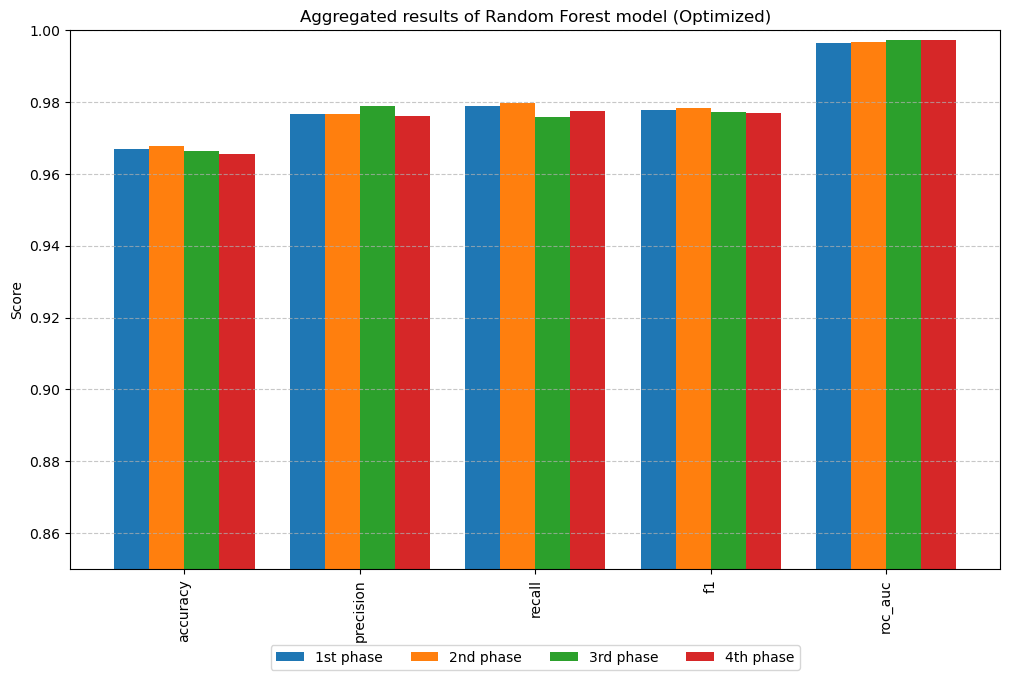

In [10]:
feature_sets = {
    "1st phase": X.drop(columns=['Following/Followers', 'Following/Posts', 'Followers/Posts']).columns.tolist(),
    "2nd phase": X.drop(columns=['Following/Posts', 'Followers/Posts']).columns.tolist(),
    "3rd phase": X.drop(columns=['Following/Followers']).columns.tolist(),
    "4th phase": X.columns.tolist() 
}
rf_params = {
    'n_estimators': 100,      # מספר העצים ביער
    'max_depth': 10,          # עומק מקסימלי למניעת overfitting
    'min_samples_split': 5,   # מינימום דגימות לפיצול צומת
    'random_state': 42,       # לשמירה על תוצאות עקביות
    'n_jobs': -1              # שימוש בכל ליבות המעבד להאצה
}
all_metrics = []

# 4. לולאת אימון והערכה
for name, features in feature_sets.items():
    X_train_sub = X_train[features]
    X_test_sub = X_test[features]
    
    # אימון
    model = RandomForestClassifier(**rf_params)
    model.fit(X_train_sub, y_train)
    
    # חיזוי
    y_pred = model.predict(X_test_sub)
    y_probs = model.predict_proba(X_test_sub)[:, 1]
    
    # חישוב 5 המדדים
    metrics = {
        "Phase": name,
        "accuracy": accuracy_score(y_test, y_pred),# אחוז התחזיות הנכונות מכלל התחזיות
        "precision": precision_score(y_test, y_pred), #מתוך מה שהמודל חזה כחיובי — כמה באמת חיוביים
        "recall": recall_score(y_test, y_pred),#מתוך המקרים האמיתיים החיוביים — כמה המודל תפס
        "f1": f1_score(y_test, y_pred),#ממוצע הרמוני בין precision ל-recall
        "roc_auc": roc_auc_score(y_test, y_probs) #כמה טוב המודל מפריד בין המחלקות בכל סף אפשרי
    }
    all_metrics.append(metrics)

# 5. הצגת התוצאות בטבלה מסודרת
results_df = pd.DataFrame(all_metrics).set_index("Phase")
print(results_df.round(4))
results_df.T.plot(kind='bar', figsize=(12, 7), width=0.8)
plt.title("Aggregated results of Random Forest model (Optimized)")
plt.ylabel("Score")
plt.ylim(0.85, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=4)
plt.show()